In [32]:
# ============================================
# ДИАГНОСТИЧЕСКИЙ БЛОК
# ============================================

print("\n" + "="*50)
print("ДИАГНОСТИКА")
print("="*50)

# 1. Проверяем форму image_rgb
print(f"1. Форма image_rgb: {image_rgb.shape}")
print(f"   Должно быть (28, 28, 3)")

# 2. Проверяем функцию predict_proba
test_input = np.array([image_rgb])
test_output = predict_proba(test_input)
print(f"\n2. predict_proba работает:")
print(f"   Вход: {test_input.shape}")
print(f"   Выход: {test_output.shape}")
print(f"   Вероятности для первых 5 классов: {test_output[0][:5]}")

# 3. Проверяем explanation
print(f"\n3. Explanation:")
print(f"   top_labels: {explanation.top_labels}")
print(f"   Количество классов в local_exp: {len(explanation.local_exp)}")

# 4. Проверяем веса
if top_label in explanation.local_exp:
    weights = dict(explanation.local_exp[top_label])
    print(f"\n4. Веса для класса {top_label}:")
    print(f"   Количество суперпикселей: {len(weights)}")
    if len(weights) > 0:
        sorted_w = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)
        print(f"   Самый важный: сегмент {sorted_w[0][0]} с весом {sorted_w[0][1]:+.4f}")
    else:
        print("   ❌ Нет весов!")
else:
    print(f"\n4. ❌ Класс {top_label} не найден в local_exp!")
    print(f"   Доступные классы: {list(explanation.local_exp.keys())}")

# 5. Проверяем сегментацию
print(f"\n5. Сегментация:")
print(f"   Уникальных сегментов: {len(np.unique(explanation.segments))}")
print(f"   Форма segments: {explanation.segments.shape}")

# 6. Проверяем маску
mask = np.zeros_like(image, dtype=bool)
if len(weights) > 0:
    top_seg = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)[0][0]
    mask[explanation.segments == top_seg] = True
    print(f"\n6. Маска для самого важного сегмента {top_seg}:")
    print(f"   Пикселей в маске: {np.sum(mask)}")
    print(f"   Это {'нормально' if np.sum(mask) > 0 else 'ПРОБЛЕМА!'}")
else:
    print("\n6. ❌ Нет сегментов для маски!")


ДИАГНОСТИКА
1. Форма image_rgb: (28, 28, 3)
   Должно быть (28, 28, 3)

2. predict_proba работает:
   Вход: (1, 28, 28, 3)
   Выход: (1, 10)
   Вероятности для первых 5 классов: [0. 0. 0. 0. 0.]

3. Explanation:
   top_labels: [np.int64(7)]
   Количество классов в local_exp: 1

4. Веса для класса 7:
   Количество суперпикселей: 1
   Самый важный: сегмент 0 с весом +0.0456

5. Сегментация:
   Уникальных сегментов: 1
   Форма segments: (28, 28)

6. Маска для самого важного сегмента 0:
   Пикселей в маске: 784
   Это нормально


Загрузка MNIST...
Обучающая: (56000, 784), Тестовая: (14000, 784)
Обучение модели...
Точность: 0.9640

Пример #0
Истинная цифра: 7
Предсказанная цифра: 7

Создание объяснения LIME...


100%|██████████| 500/500 [00:01<00:00, 380.04it/s]


Создано суперпикселей: 49

Класс для объяснения: 7
Найдено 49 суперпикселей с весами
Топ-5 важных:
  1. Сегмент 25: +0.1429 (размер: 16 пикселей)
  2. Сегмент 17: +0.1232 (размер: 16 пикселей)
  3. Сегмент 16: +0.1011 (размер: 16 пикселей)
  4. Сегмент 18: +0.0689 (размер: 16 пикселей)
  5. Сегмент 32: +0.0508 (размер: 16 пикселей)

Маска содержит 80 пикселей

Визуализация...


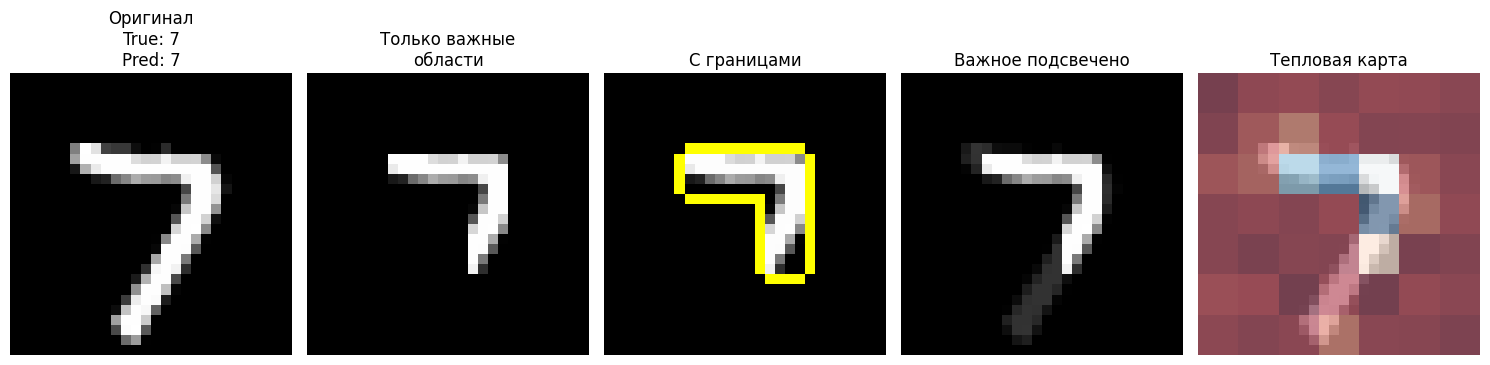


ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ВАЖНЫХ ОБЛАСТЯХ
 1. Сегмент  25: +0.1429 | Пикселей:   16 | Яркость: 0.734 | Центр: (13.5, 17.5)
 2. Сегмент  17: +0.1232 | Пикселей:   16 | Яркость: 0.614 | Центр: (9.5, 13.5)
 3. Сегмент  16: +0.1011 | Пикселей:   16 | Яркость: 0.564 | Центр: (9.5, 9.5)
 4. Сегмент  18: +0.0689 | Пикселей:   16 | Яркость: 0.794 | Центр: (9.5, 17.5)
 5. Сегмент  32: +0.0508 | Пикселей:   16 | Яркость: 0.474 | Центр: (17.5, 17.5)
 6. Сегмент   9: +0.0248 | Пикселей:   16 | Яркость: 0.099 | Центр: (5.5, 9.5)
 7. Сегмент  45: +0.0205 | Пикселей:   16 | Яркость: 0.234 | Центр: (25.5, 13.5)
 8. Сегмент  26: +0.0176 | Пикселей:   16 | Яркость: 0.093 | Центр: (13.5, 21.5)
 9. Сегмент  15: +0.0147 | Пикселей:   16 | Яркость: 0.150 | Центр: (9.5, 5.5)
10. Сегмент  37: -0.0111 | Пикселей:   16 | Яркость: 0.065 | Центр: (21.5, 9.5)

✅ Готово!


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import lime
import lime.lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
print("Загрузка MNIST...")
mnist = fetch_openml('mnist_784', parser='auto', as_frame=False)
X = mnist.data.astype('float32') / 255.0
y = mnist.target.astype('int')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая: {X_train.shape}, Тестовая: {X_test.shape}")

# ============================================
# 2. ОБУЧЕНИЕ МОДЕЛИ
# ============================================
print("Обучение модели...")
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Точность: {accuracy:.4f}")

# ============================================
# 3. ФУНКЦИЯ ДЛЯ LIME
# ============================================
def predict_proba(images):
    """Принимает изображения в любом формате, возвращает вероятности"""
    processed = []
    for img in images:
        # Если RGB (3 канала) - берем первый
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = img[:, :, 0]
        
        # Изменяем размер если нужно
        if img.shape != (28, 28):
            img = resize(img, (28, 28), preserve_range=True)
        
        processed.append(img.flatten())
    
    processed = np.array(processed)
    
    if processed.shape[1] != 784:
        if processed.shape[1] > 784:
            processed = processed[:, :784]
        else:
            pad = 784 - processed.shape[1]
            processed = np.pad(processed, ((0,0), (0,pad)))
    
    return model.predict_proba(processed)

# ============================================
# 4. ФУНКЦИЯ СЕГМЕНТАЦИИ (ИСПРАВЛЕННАЯ)
# ============================================
def segmentation_fn(image):
    """Создает суперпиксели для изображения"""
    # Если изображение RGB, конвертируем в grayscale
    if len(image.shape) == 3 and image.shape[2] == 3:
        from skimage.color import rgb2gray
        image_gray = rgb2gray(image)
    else:
        image_gray = image
    
    # Создаем суперпиксели - для 2D изображения channel_axis=None
    segments = slic(
        image_gray,
        n_segments=50,      # Количество суперпикселей
        compactness=10,
        sigma=1,
        start_label=0,
        channel_axis=None   # ← Явно указываем, что это grayscale
    )
    return segments

# ============================================
# 5. ВЫБОР ПРИМЕРА
# ============================================
idx = 0
image = X_test[idx].reshape(28, 28)
image_rgb = np.stack([image, image, image], axis=2)

true_label = y_test[idx]
predicted_label = model.predict([X_test[idx]])[0]

print(f"\nПример #{idx}")
print(f"Истинная цифра: {true_label}")
print(f"Предсказанная цифра: {predicted_label}")

# ============================================
# 6. СОЗДАНИЕ ОБЪЯСНЕНИЯ (ДЛЯ СТАРОЙ ВЕРСИИ LIME)
# ============================================
print("\nСоздание объяснения LIME...")

explainer = lime.lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image_rgb,
    predict_proba,
    top_labels=5,
    hide_color=0,
    num_samples=500,
    random_seed=42,
    segmentation_fn=segmentation_fn  # ← Передаем функцию сегментации
)

# Проверяем сегментацию
n_segments = len(np.unique(explanation.segments))
print(f"Создано суперпикселей: {n_segments}")

# ============================================
# 7. ПОЛУЧАЕМ ВАЖНЫЕ ОБЛАСТИ
# ============================================
top_label = explanation.top_labels[0]
print(f"\nКласс для объяснения: {top_label}")

weights = dict(explanation.local_exp[top_label])
sorted_weights = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)

print(f"Найдено {len(weights)} суперпикселей с весами")
print("Топ-5 важных:")
for i, (seg, w) in enumerate(sorted_weights[:5]):
    size = np.sum(explanation.segments == seg)
    print(f"  {i+1}. Сегмент {seg}: {w:+.4f} (размер: {size} пикселей)")

# Создаем маску для топ-5
top_segments = [seg for seg, w in sorted_weights[:5]]
mask = np.zeros_like(image, dtype=bool)
for seg_id in top_segments:
    mask[explanation.segments == seg_id] = True

print(f"\nМаска содержит {np.sum(mask)} пикселей")

# Создаем изображение с важными областями
important_image = np.zeros_like(image)
important_image[mask] = image[mask]

# ============================================
# 8. ВИЗУАЛИЗАЦИЯ
# ============================================
print("\nВизуализация...")

plt.figure(figsize=(15, 5))

# 1. Оригинал
plt.subplot(1, 5, 1)
plt.imshow(image, cmap='gray')
plt.title(f"Оригинал\nTrue: {true_label}\nPred: {predicted_label}")
plt.axis('off')

# 2. Только важные области
plt.subplot(1, 5, 2)
plt.imshow(important_image, cmap='gray')
plt.title("Только важные\nобласти")
plt.axis('off')

# 3. Важные области с границами
plt.subplot(1, 5, 3)
plt.imshow(mark_boundaries(important_image, mask), cmap='gray')
plt.title("С границами")
plt.axis('off')

# 4. Важные области на оригинале
plt.subplot(1, 5, 4)
overlay = image.copy()
overlay[~mask] = overlay[~mask] * 0.2
plt.imshow(overlay, cmap='gray')
plt.title("Важное подсвечено")
plt.axis('off')

# 5. Тепловая карта
plt.subplot(1, 5, 5)
heatmap = np.zeros_like(image)
for segment, weight in weights.items():
    heatmap[explanation.segments == segment] = weight
plt.imshow(image, cmap='gray', alpha=0.5)
plt.imshow(heatmap, cmap='RdBu', alpha=0.5)
plt.title("Тепловая карта")
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================
# 9. ДЕТАЛЬНАЯ ИНФОРМАЦИЯ
# ============================================
print("\n" + "="*50)
print("ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ВАЖНЫХ ОБЛАСТЯХ")
print("="*50)

for i, (segment, weight) in enumerate(sorted_weights[:10]):
    seg_mask = (explanation.segments == segment)
    size = np.sum(seg_mask)
    avg_brightness = image[seg_mask].mean() if size > 0 else 0
    
    if size > 0:
        y_coords, x_coords = np.where(seg_mask)
        center_y, center_x = y_coords.mean(), x_coords.mean()
        print(f"{i+1:2d}. Сегмент {segment:3d}: {weight:+.4f} | "
              f"Пикселей: {size:4d} | Яркость: {avg_brightness:.3f} | "
              f"Центр: ({center_y:.1f}, {center_x:.1f})")
    else:
        print(f"{i+1:2d}. Сегмент {segment:3d}: {weight:+.4f} | Пикселей: {size:4d}")

print("\n✅ Готово!")

https://github.com/marcotcr/lime

